In [1]:
import os
import glob
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
def compile_lfp_stats(pickle_dir="/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles"):
    all_files = glob.glob(os.path.join(pickle_dir, "*_sliding_stats.pkl"))
    
    master_stats_rows = []
    master_traces = []
    
    for file_path in all_files:
        with open(file_path, 'rb') as f:
            cell_data = pickle.load(f)
            
        cell_id = cell_data.get("cell_id", "Unknown")
        
        for feature_name, data in cell_data.items():
            if feature_name == "cell_id": continue 
                
            # --- 1. EXTRACT STATS ---
            for pair in data.get("pairwise_stats", []):
                g1 = pair['group_1'].split(': ')[-1] if ':' in pair['group_1'] else pair['group_1']
                g2 = pair['group_2'].split(': ')[-1] if ':' in pair['group_2'] else pair['group_2']
                
                master_stats_rows.append({
                    "cell_id": cell_id,
                    "spike_feature": pair.get("spike_feature", "Unknown"), # Pulled from inside the stats!
                    "lfp_feature": feature_name,
                    "window_start": pair["window_start"],
                    "window_end": pair["window_end"],
                    "group_1": g1,
                    "group_2": g2,
                    "comparison": f"{g1} vs {g2}",
                    "p_value": pair["p_value"],
                    "cohens_d": pair["cohens_d"]
                })
                
            # --- 2. EXTRACT TRACES ---
            for spike_feature, t_data in data.get("trace_data", {}).items():
                master_traces.append({
                    "cell_id": cell_id,
                    "spike_feature": spike_feature,
                    "lfp_feature": feature_name,
                    "trace_data": t_data
                })
                
    return pd.DataFrame(master_stats_rows), master_traces



In [14]:
pop_stats[0]

,cell_id,spike_feature,lfp_feature,window_start,window_end,group_1,group_2,comparison,p_value,cohens_d
0,c19,log_isi_cluster,Aperiodic Exponent,0.553134,0.603134,low,high,low vs high,0.048897,0.069809
1,c19,spk_times_ms_cluster,Aperiodic Exponent,-0.174741,-0.124741,low,high,low vs high,0.035056,0.078845
2,c19,spk_times_ms_cluster,Aperiodic Exponent,0.000259,0.050259,low,high,low vs high,0.039892,0.077515
3,c19,spk_times_ms_cluster,Aperiodic Exponent,0.775259,0.825259,low,high,low vs high,0.032176,0.080178
4,c19,spk_times_ms_cluster,Aperiodic Offset,-0.174741,-0.124741,low,high,low vs high,0.045185,0.075000
...,...,...,...,...,...,...,...,...,...,...
141,c45,peak_width_cluster,r-squared,-0.196882,-0.046882,low,mid,low vs mid,0.007828,0.088007
142,c45,peak_width_cluster,r-squared,0.178118,0.378118,low,high,low vs high,0.012891,0.166814
143,c45,peak_width_cluster,r-squared,0.178118,0.378118,mid,high,mid vs high,0.000808,0.223568
144,c45,peak_width_cluster,r-squared,0.703118,0.878118,low,high,low vs high,0.001572,0.222453


In [11]:
# Run the compiler
pop_stats = compile_lfp_stats()
df_pop_stats = pop_stats[0]
pop_traces = pop_stats[1]

/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


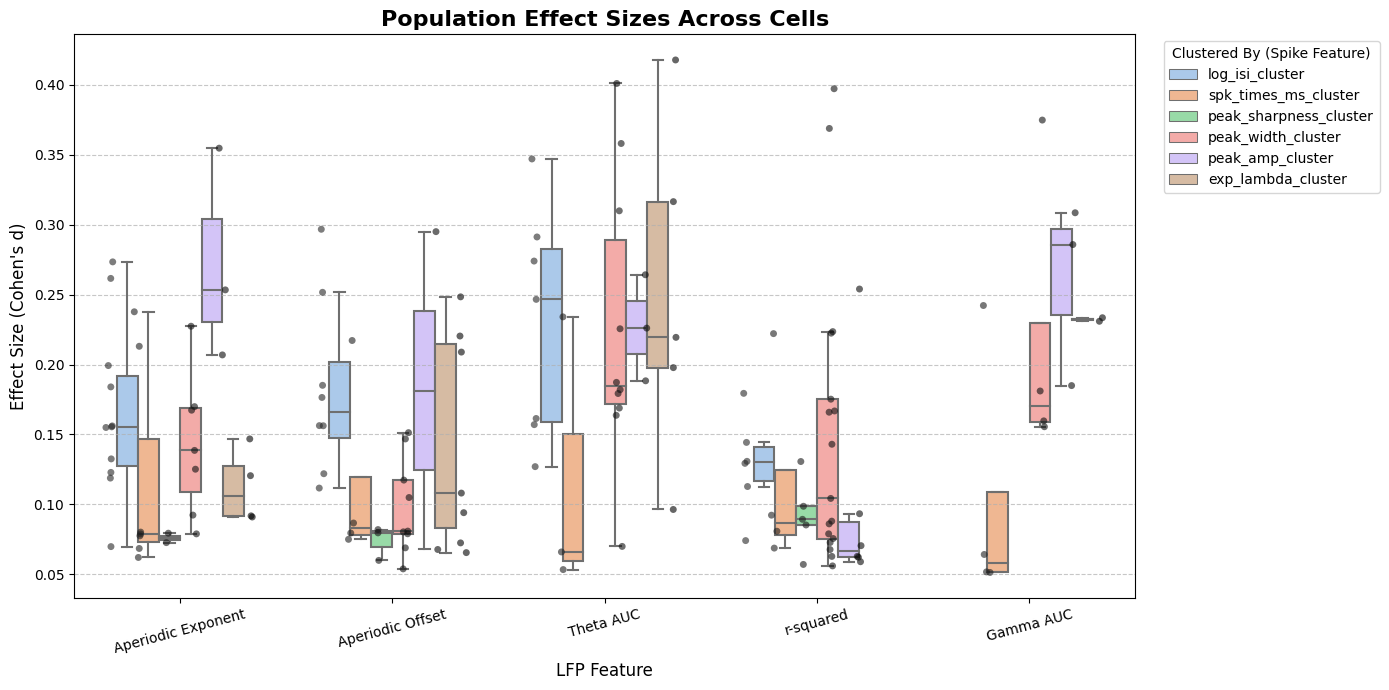

In [12]:


# Optional: filter to only look at specific comparisons, e.g., "low vs high"
# df_plot = df_pop_stats[df_pop_stats["comparison"] == "low vs high"]
df_plot = df_pop_stats.copy()

if not df_plot.empty:
    plt.figure(figsize=(14, 7))
    
    # Create a boxplot grouped by LFP Feature, colored by Spike Feature
    sns.boxplot(
        data=df_plot, 
        x="lfp_feature", 
        y="cohens_d", 
        hue="spike_feature", 
        palette="pastel",
        width=0.6,
        fliersize=0
    )
    
    # Overlay the individual cell data points
    sns.stripplot(
        data=df_plot, 
        x="lfp_feature", 
        y="cohens_d", 
        hue="spike_feature",
        dodge=True,
        color="black", 
        alpha=0.6, 
        jitter=True,
        legend=False
    )

    plt.title("Population Effect Sizes Across Cells", fontweight="bold", fontsize=16)
    plt.ylabel("Effect Size (Cohen's d)", fontsize=12)
    plt.xlabel("LFP Feature", fontsize=12)
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Fix the legend position
    plt.legend(title="Clustered By (Spike Feature)", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty. Make sure Cell 1 loaded the pickles correctly!")


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


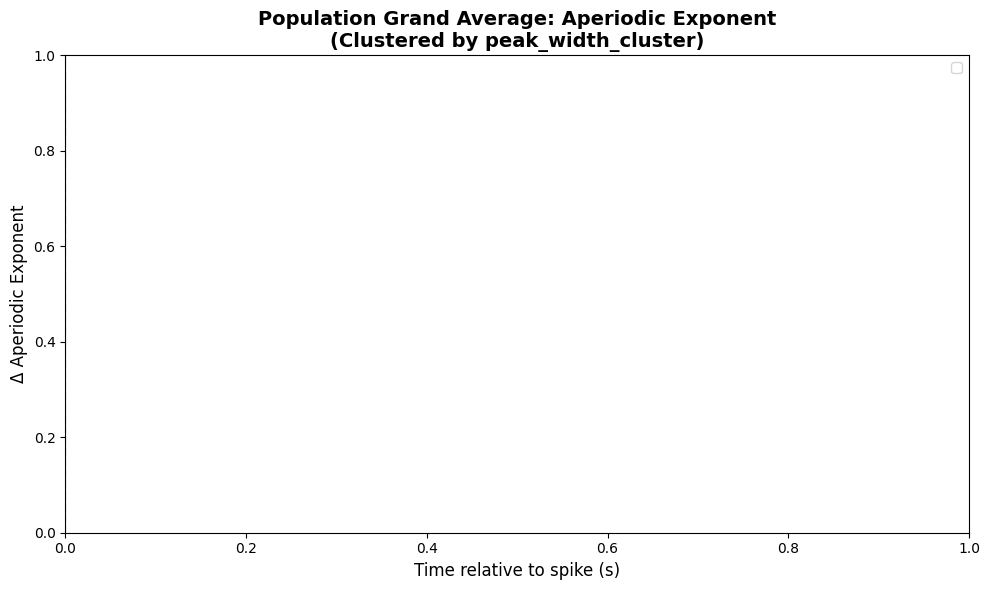

In [15]:
# --- CELL 3: GRAND AVERAGE TRACES ---


# Define exactly what you want to plot the grand average for:
target_lfp_feature = "Aperiodic Exponent"
target_spike_feature = "peak_width_cluster"

# Filter the traces list for these specific features
filtered_traces = [
    t for t in pop_traces 
    if t["lfp_feature"] == target_lfp_feature and t["spike_feature"] == target_spike_feature
]

if not filtered_traces:
    print(f"No traces found for {target_lfp_feature} clustered by {target_spike_feature}.")
else:
    # 1. Extract the time grid (assuming they are all the same)
    Tgrid = filtered_traces[0]["trace_data"]["Tgrid"]
    
    # 2. Set up dictionaries to hold the stacked arrays for each cluster
    cluster_names = ["Cluster: low", "Cluster: mid", "Cluster: high"]
    colors_dict = {"Cluster: low": "#1f77b4", "Cluster: mid": "#2ca02c", "Cluster: high": "#ff7f0e"}
    stacked_data = {c: [] for c in cluster_names}
    
    # 3. Loop through cells and stack their mean traces
    for cell_record in filtered_traces:
        td = cell_record["trace_data"]
        
        # 'td' keys are the cluster names (e.g., 'Cluster: low')
        # We make it case-insensitive just in case
        td_lower_keys = {k.lower(): k for k in td.keys()}
        
        for c_name in cluster_names:
            if c_name in td_lower_keys:
                actual_key = td_lower_keys[c_name]
                # Grab the mean trace for this specific cell's cluster
                cell_mean_trace = td[actual_key]["mean"]
                if len(cell_mean_trace) == len(Tgrid):
                    stacked_data[c_name].append(cell_mean_trace)

    # 4. Plot the Grand Averages
    plt.figure(figsize=(10, 6))
    
    for c_name in cluster_names:
        if len(stacked_data[c_name]) > 0:
            # Convert list of arrays to a 2D numpy array (Cells x Time)
            matrix = np.vstack(stacked_data[c_name])
            
            # Calculate Grand Mean and Standard Error of the Mean (SEM) across cells
            grand_mean = np.nanmean(matrix, axis=0)
            grand_sem = np.nanstd(matrix, axis=0) / np.sqrt(matrix.shape[0])
            
            # Plot
            color = colors_dict[c_name]
            label_clean = c_name.split(': ')[-1].capitalize()
            
            plt.plot(Tgrid, grand_mean, label=f"{label_clean} (n={matrix.shape[0]} cells)", color=color, lw=2.5)
            plt.fill_between(Tgrid, grand_mean - grand_sem, grand_mean + grand_sem, color=color, alpha=0.2, lw=0)

    # Aesthetics
    plt.axvline(0, color="k", ls="--", lw=1.5)
    plt.title(f"Population Grand Average: {target_lfp_feature}\n(Clustered by {target_spike_feature})", fontweight="bold", fontsize=14)
    plt.xlabel("Time relative to spike (s)", fontsize=12)
    plt.ylabel(f"Δ {target_lfp_feature}", fontsize=12)
    plt.legend(loc="upper right", frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.show()